In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import shap

# 1. Load the data (use a sample first if the file is massive)
df = pd.read_csv("accepted_loans.csv", low_memory=False)

# 2. Engineer the Target Variable (Probability of Default)
def classify_default(status):
    bad_statuses = ['Charged Off', 'Default', 'Late (31-120 days)', 'Does not meet the credit policy. Status:Charged Off']
    good_statuses = ['Fully Paid', 'Current', 'In Grace Period', 'Late (16-30 days)', 'Meets credit policy. Status:Fully Paid']
    
    if status in bad_statuses:
        return 1
    elif status in good_statuses:
        return 0
    return np.nan

df['default_flag'] = df['loan_status'].apply(classify_default)

# Drop any rows where the status is unknown
df = df.dropna(subset=['default_flag'])

C:\Users\Ashvik\AppData\Local\Temp\ipykernel_9596\2267813003.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['default_flag'] = df['loan_status'].apply(classify_default)


In [3]:
# 3. Define columns to drop
leakage_and_useless_cols = [
    # Post-Origination Leakage (The Model Cheats if it sees these)
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 
    'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 
    'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',
    
    # Hardship & Settlement Data (Only happens AFTER default)
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status', 
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date', 
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 'hardship_loan_status', 
    'orig_projected_additional_accrued_interest', 'hardship_payoff_balance_amount', 
    'hardship_last_payment_amount', 'debt_settlement_flag', 'debt_settlement_flag_date', 
    'settlement_status', 'settlement_date', 'settlement_amount', 'settlement_percentage', 
    'settlement_term',
    
    # Administrative & ID Columns
    'id', 'member_id', 'url', 'desc', 'title', 'zip_code', 'issue_d', 
    'pymnt_plan', 'initial_list_status', 'policy_code',
    
    # The original target and highly correlated funding amounts
    'loan_status', 'funded_amnt', 'funded_amnt_inv'
]

# Drop them
df_clean = df.drop(columns=leakage_and_useless_cols, errors='ignore')

In [4]:
# 4. Drop columns missing more than 90% of their data
missing_pct = df_clean.isnull().mean()
cols_to_keep = missing_pct[missing_pct < 0.90].index
df_clean = df_clean[cols_to_keep]

# 5. Split features (X) and target (y)
y = df_clean['default_flag']
X = df_clean.drop(columns=['default_flag'])

# 6. Train/Test Split (Do this BEFORE imputation to prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
# 7. Separate numerical and categorical columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# 8. Quick Imputation & Encoding
# For numerical: XGBoost can technically handle NaNs, but a median fill is safer for baseline
X_train[num_cols] = X_train[num_cols].fillna(X_train[num_cols].median())
X_test[num_cols] = X_test[num_cols].fillna(X_train[num_cols].median()) # Use Train median!

# For categorical: Fill missing with "Unknown" and use Pandas Factorize (Ordinal Encoding)
for col in cat_cols:
    X_train[col] = X_train[col].fillna("Unknown")
    X_test[col] = X_test[col].fillna("Unknown")
    
    # Simple integer encoding for tree models
    X_train[col], uniques = pd.factorize(X_train[col])
    
    # Map the test set to the same integers
    col_mapping = {val: i for i, val in enumerate(uniques)}
    X_test[col] = X_test[col].map(col_mapping).fillna(-1) # -1 for unseen categories

C:\Users\Ashvik\AppData\Local\Temp\ipykernel_9596\4001934860.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns


In [6]:
# 9. Initialize and Train XGBoost Classifier
# scale_pos_weight helps if defaults are rare (e.g., 80% good / 20% bad -> weight=4)
pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=pos_weight,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1 # Use all CPU cores
)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

# 10. Predict Probabilities
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# 11. Evaluate
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {auc_score:.4f}")

Training XGBoost...
ROC-AUC Score: 0.7420


Calculating SHAP values...


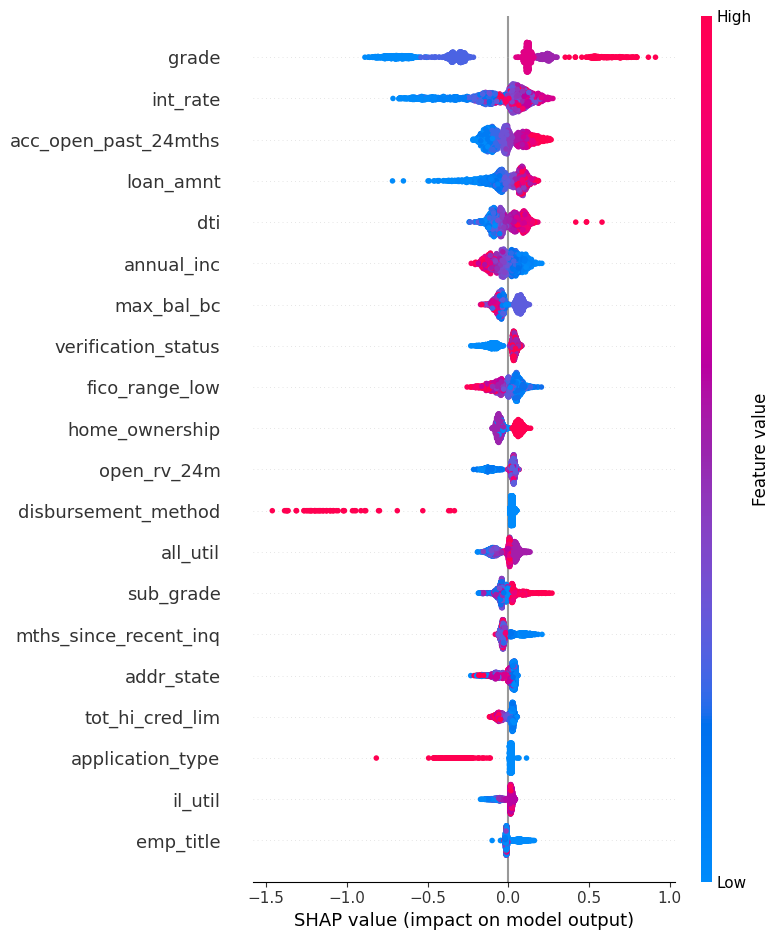

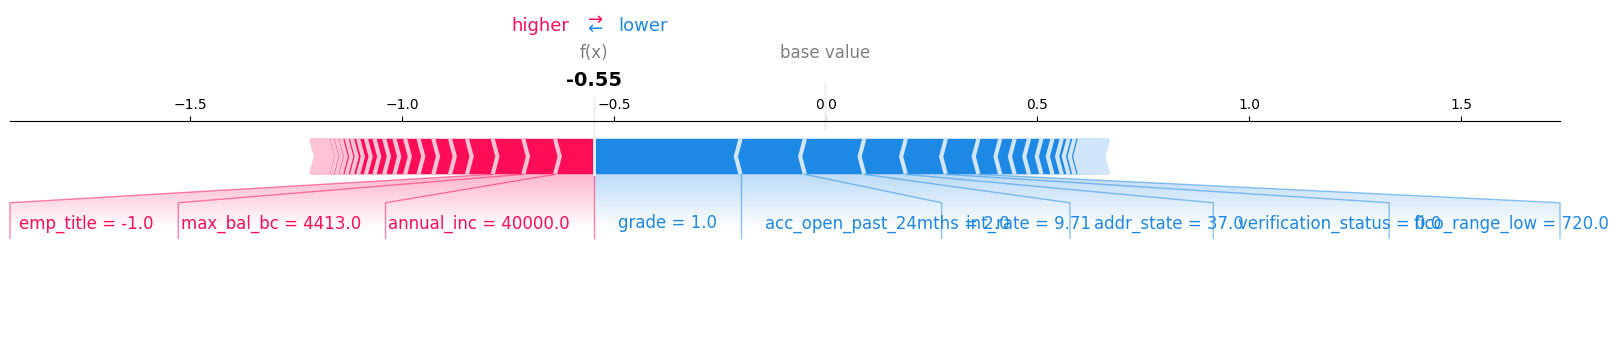

In [8]:
# 12. Generate SHAP values
print("Calculating SHAP values...")
explainer = shap.TreeExplainer(xgb_model)

# SHAP calculations can be slow, so we explain a sample of the test set
X_test_sample = X_test.sample(2000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# 13. Plot the global feature importance
# This will show you exactly which features drive defaults (e.g., high dti, low fico)
shap.summary_plot(shap_values, X_test_sample)

# 14. Explain a single applicant (e.g., the first person in our sample)
single_shap_values = explainer.shap_values(X_test_sample.iloc[[0]])

shap.force_plot(
    explainer.expected_value,
    single_shap_values[0],
    X_test_sample.iloc[0],
    matplotlib=True
)